<!-- Header Section -->
<div style="
    background: linear-gradient(135deg, #2A7B9B 0%, #57C785 100%);
    padding: 35px;
    border-radius: 18px;
    text-align: center;
    box-shadow: 0 6px 14px rgba(0,0,0,0.15);
">
    <h1 style="
        color: #1f1f1f;
        font-size: 44px;
        margin: 0;
        letter-spacing: 1px;
    ">
        🎬 Top 250 IMDB Movie Dataset 
    </h1>
    <h2 style="
        color: #2e2e2e;
        font-size: 26px;
        margin-top: 15px;
        font-weight: 400;
    ">
        📈 Exploratory Data Analysis 
    </h2>
<!-- Header Section
    <p style="
        color: #333;
        font-size: 17px;
        margin-top: 22px;
        line-height: 1.7;
    ">
        <strong> </strong> <br>
        <strong> </strong> <br>
        <strong> </strong> <br>
    </p> -->
</div>

<div style="
    background: #14E36A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
        🛠️ Imports & Loading Dataset 
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    ">
        Preparing the workspace, installing dependencies, and loading the dataset from external sources.
    </p>
</div>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 
sns.set_theme(style="whitegrid")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv')

<div style="
    background: #F7A80A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
    📊 Exploratory Data Analysis (EDA)
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    ">
        Review of features and data cleaning
    </p>
</div>


In [3]:
df.head()

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
0,1,The Shawshank Redemption,1994,NaN,142,R,IMDb Top 250
1,2,The Godfather,1972,NaN,175,R,IMDb Top 250
2,3,The Dark Knight,2008,NaN,152,PG-13,IMDb Top 250
3,4,The Godfather Part II,1974,NaN,202,R,IMDb Top 250
4,5,12 Angry Men,1957,NaN,96,Approved,IMDb Top 250


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              250 non-null    int64  
 1   Title             250 non-null    object 
 2   Year              250 non-null    int64  
 3   Rating            0 non-null      float64
 4   Duration_Minutes  250 non-null    int64  
 5   Certificate       245 non-null    object 
 6   Source            250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


**There are 250 rows, with all Ratings being null and 5 Certificates being null. The Rating column will be removed as it is not useful, and the missing Certificates will be filled in.**

Rank                  0
Title                 0
Year                  0
Rating              250
Duration_Minutes      0
Certificate           5
Source                0
dtype: int64


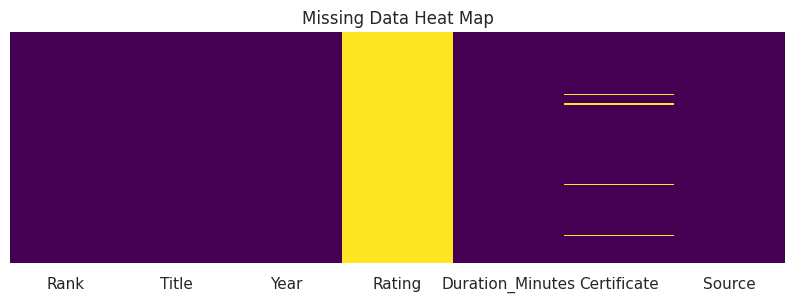

In [5]:
print(df.isnull().sum())
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heat Map')
plt.show()

In [6]:
# Remove the Rating column
df = df.drop('Rating',axis=1)

In [7]:
# Show the rows where the Certificate is null
filas_con_nulos = df[df['Certificate'].isnull()]
display(filas_con_nulos.head())

,Rank,Title,Year,Duration_Minutes,Certificate,Source
68,69,12th Fail,2023,147,NaN,IMDb Top 250
77,78,Your Name.,2016,106,NaN,IMDb Top 250
78,79,Das Boot,1981,149,NaN,IMDb Top 250
165,166,The Chaos Class Failed the Class,1975,95,NaN,IMDb Top 250
220,221,Maharaja,2024,141,NaN,IMDb Top 250


In [8]:
df['Certificate'] = df['Certificate'].fillna('Not specified')
no_cert = df[df['Certificate'] == 'Not specified']
print(no_cert)

     Rank                             Title  Year  Duration_Minutes  \
68     69                         12th Fail  2023               147   
77     78                        Your Name.  2016               106   
78     79                          Das Boot  1981               149   
165   166  The Chaos Class Failed the Class  1975                95   
220   221                          Maharaja  2024               141   

       Certificate        Source  
68   Not specified  IMDb Top 250  
77   Not specified  IMDb Top 250  
78   Not specified  IMDb Top 250  
165  Not specified  IMDb Top 250  
220  Not specified  IMDb Top 250  


Rank                0
Title               0
Year                0
Duration_Minutes    0
Certificate         0
Source              0
dtype: int64


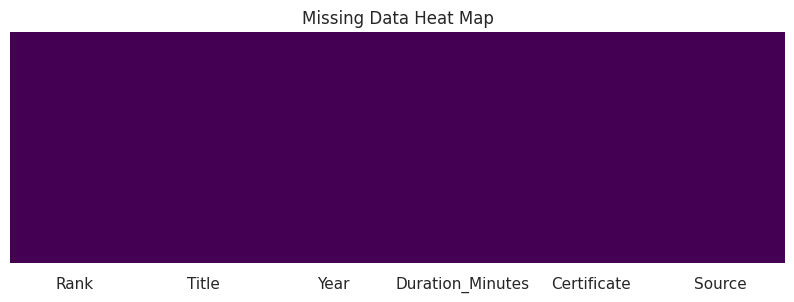

In [9]:
print(df.isnull().sum())
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heat Map')
plt.show()

In [10]:
df.describe()

,Rank,Year,Duration_Minutes
count,250.000000,250.000000,250.000000
mean,125.500000,1988.620000,131.516000
std,72.312977,25.552442,35.747128
min,1.000000,1921.000000,45.000000
25%,63.250000,1973.000000,108.250000
50%,125.500000,1995.000000,127.500000
75%,187.750000,2009.000000,147.750000
max,250.000000,2025.000000,374.000000


<div style="
    background: #F7A80A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
        🔎 Statistical Analysis
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    "> <strong> The following questions are to be answered: </strong> <br>
        <strong> 1. How many movies are there per decade? </strong> <br>
        <strong> 2. Has the running time changed over the years?</strong> <br>
        <strong> 3. Distribution of Certificates </strong> <br>
        <strong> 4.Ranking vs. Decades (Who dominates the top spots?)</strong> <br>
    </p>
</div>


Decade
1920     6
1930     6
1940    11
1950    21
1960    16
1970    19
1980    26
1990    39
2000    47
2010    45
2020    14
Name: count, dtype: int64


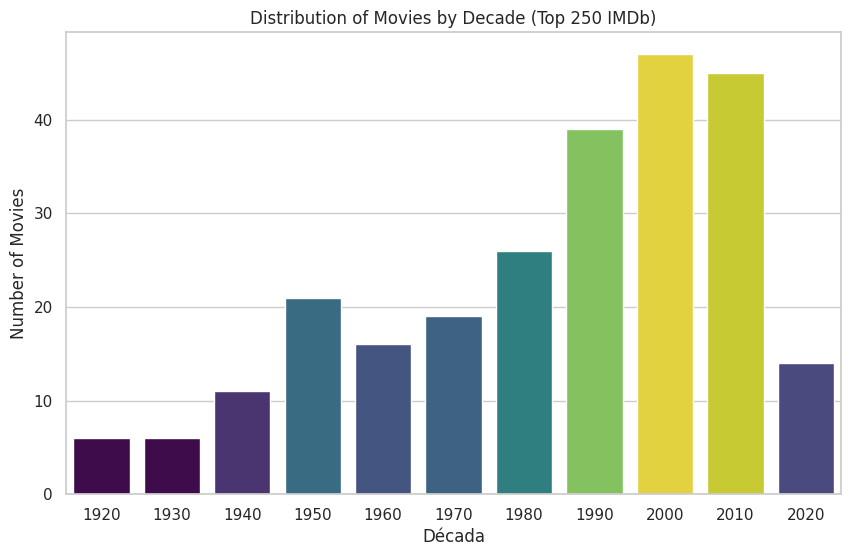

In [11]:
# 1. How many movies are there per decade?
df['Decade'] = (df['Year'] // 10) * 10
print(df['Decade'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.barplot(
    x=df['Decade'].value_counts().sort_index().index, 
    y=df['Decade'].value_counts().sort_index().values, 
    palette="viridis",
    hue=df['Decade'].value_counts().sort_index().values,  # Asignas la misma variable al color
    legend=False  )
plt.title('Distribution of Movies by Decade (Top 250 IMDb)')
plt.xlabel('Década')
plt.ylabel('Number of Movies')
plt.show()

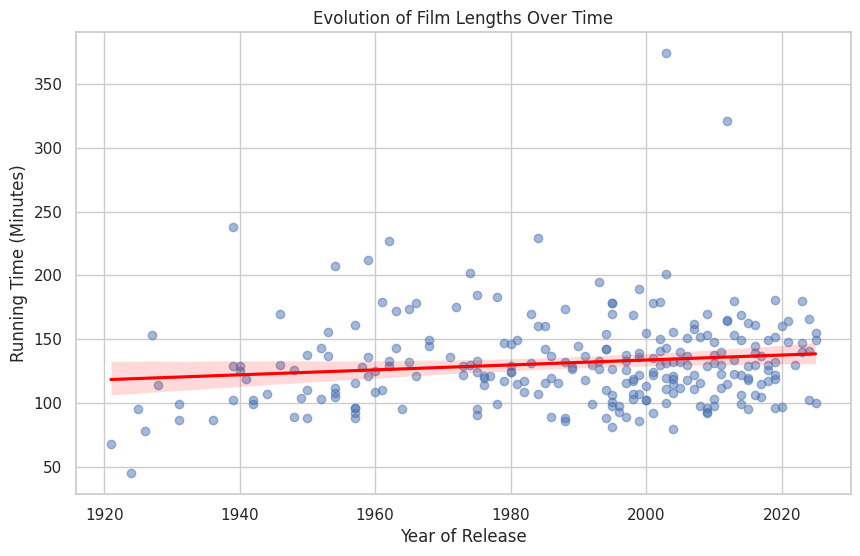

The average running time is: 131.516 minutes


In [12]:
#2 Has the running time changed over the years?
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Year', y='Duration_Minutes', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Evolution of Film Lengths Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Running Time (Minutes)')
plt.show()
print(f"The average running time is: {df['Duration_Minutes'].mean()} minutes")

    Decade  Duration_Minutes
0     1920         92.166667
1     1930        123.666667
2     1940        118.181818
3     1950        126.333333
4     1960        145.062500
5     1970        133.894737
6     1980        131.730769
7     1990        126.820513
8     2000        134.170213
9     2010        135.777778
10    2020        141.357143


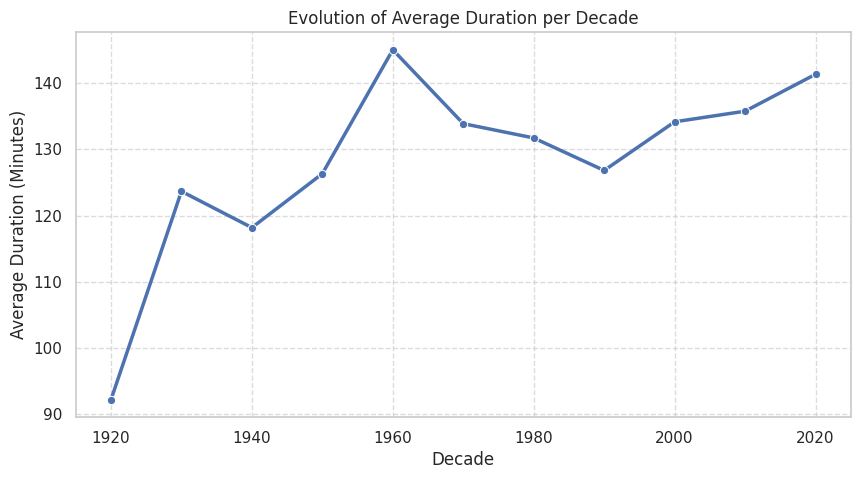

In [13]:
duration_per_decade = df.groupby('Decade')['Duration_Minutes'].mean().reset_index()
print(duration_per_decade)

plt.figure(figsize=(10, 5))
sns.lineplot(data=duration_per_decade, x='Decade', y='Duration_Minutes', marker='o', linewidth=2.5)
plt.title('Evolution of Average Duration per Decade')
plt.xlabel('Decade')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

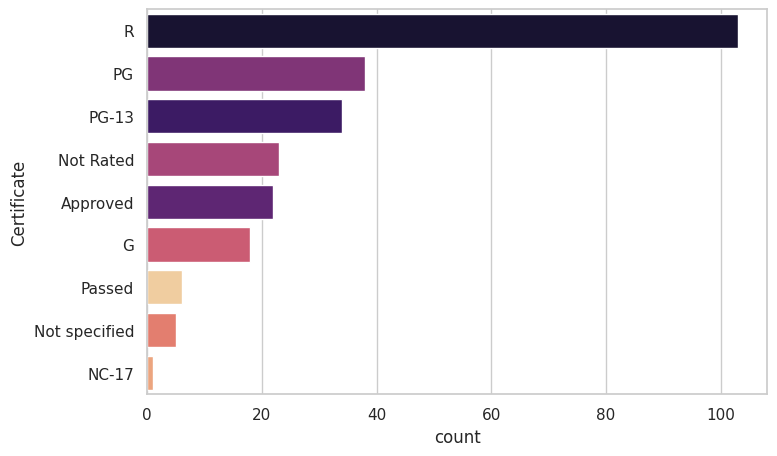

Certificate
R                103
PG                38
PG-13             34
Not Rated         23
Approved          22
G                 18
Passed             6
Not specified      5
NC-17              1
Name: count, dtype: int64


In [14]:
#3 Distribution of Certificates
plt.figure(figsize=(8, 5))
order = df['Certificate'].value_counts().index
sns.countplot(
    data=df, 
    y='Certificate', 
    order=order, 
    palette="magma", 
    hue='Certificate',  
    legend=False        
)
plt.show()
print(df['Certificate'].value_counts())

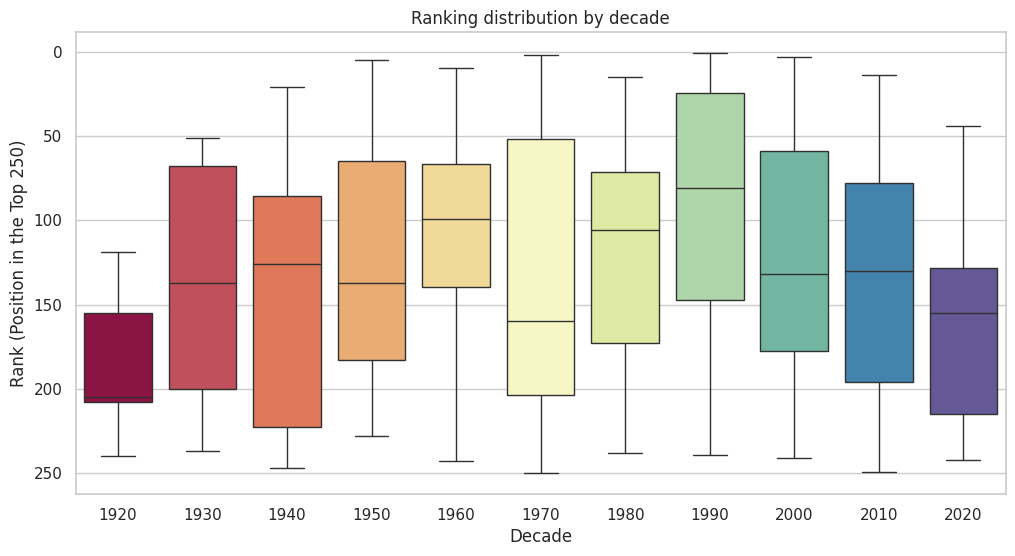

In [15]:
#4 Ranking vs. Decades (Who dominates the top spots?)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Decade', y='Rank', palette="Spectral",hue='Decade',legend=False)
plt.title('Ranking distribution by decade')
plt.xlabel('Decade')
plt.ylabel('Rank (Position in the Top 250)')
# We inverted the Y-axis because Rank 1 is the best
plt.gca().invert_yaxis() 
plt.show()


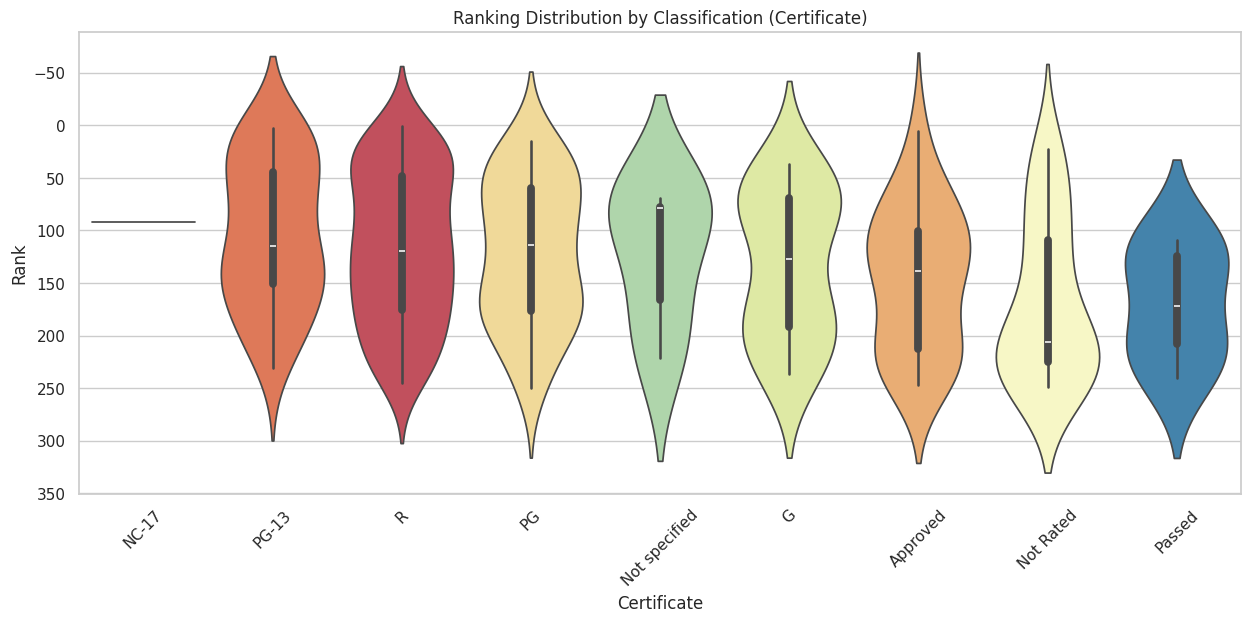

In [16]:
plt.figure(figsize=(15, 6))
# Ordenamos por el ranking promedio de cada certificado
cert_order = df.groupby('Certificate')['Rank'].mean().sort_values().index

sns.violinplot(data=df, x='Certificate', y='Rank', order=cert_order, palette="Spectral",hue='Certificate',legend=False)
plt.title('Ranking Distribution by Classification (Certificate)')
plt.xlabel('Certificate')
plt.ylabel('Rank')
plt.gca().invert_yaxis()
plt.xticks(rotation=45)
plt.show()

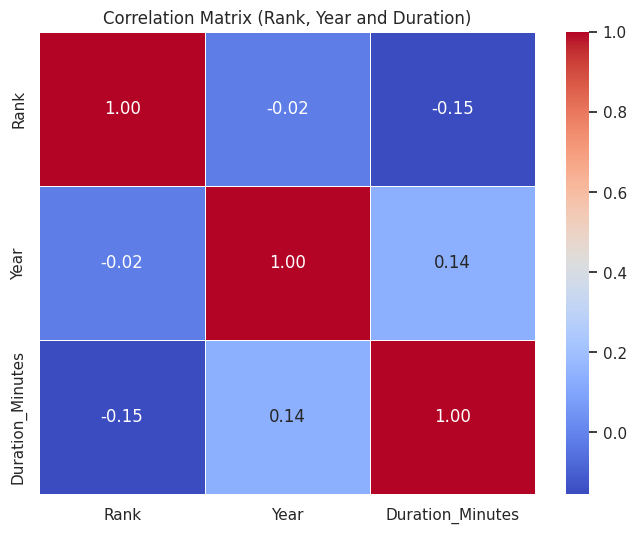

In [17]:
plt.figure(figsize=(8, 6))
# Solo seleccionamos columnas numéricas
numeric_cols = df[['Rank', 'Year', 'Duration_Minutes']]
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Rank, Year and Duration)')
plt.show()